### Plot IUIS-IEI membership among pipeline hits
### Julian Moran
### 2026-08-20

In [16]:
import boto3
import glob
import logging
import os
import s3fs

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from dotenv import load_dotenv

# Env
load_dotenv("../.env", override=True)
REPO_ROOT = os.environ["INSTALL_PATH"]
MINIO_KEY = os.environ["MINIO_KEY"]
MINIO_SECRET = os.environ["MINIO_SECRET"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

### Project status

1. Composite score currently implemented in pipeline
    - see repository `iei-project` branch `feature/pymol_composite`
    - caveat: no term in composite for penalising short / spurious alignments

<br>

2. From pipeline, >2000 protein pairs exhibit >0.8 composite score

<br>

3. No protein pairss from gold standard set are in pipeline final output
    - every single one ruled out by either DefenseFinder or FoldSeek

<br>

### Notebook goal

- Generate plots characterising how reliable the high-scoring protein pairs are as per
    + clinical significance
    + corroborating literature findings


### Data sources

1. `FILE_GOLD_STD`: in-house manual literature review
2. `FILE_IUIS_IEI`: https://iei-genetics.github.io/?utm_source=chatgpt.com
3. `FILE_COMPOSITE`: pipeline output from  https://github.com/juliandeanmoran/iei-project-pyspark; see `data/READEME_run_w_pyspark.md`

In [2]:
# ============================================================
#       Args
# ============================================================

FILE_GOLD_STD = f"{REPO_ROOT}/lit_review_manual/___bacterial_immuneSystem_goldStandard_manual_include.tsv"
FILE_IUIS_IEI = f"{REPO_ROOT}/data_sync/IUIS-IEI_geneList_cleaned.tsv"

# MinIO
BUCKET = "iei-project"
PREFIX_GOLD = "03_gold/defense_finder/"
PREFIX_SILVER = "02_silver/defense_finder/"
FILE_COMPOSITE = "composite_score.parquet/part-00000-ac5574c4-cf3c-48a9-98b6-077d4db394f9-c000.snappy.parquet"

# Dirs
OUT_DIR_PLOT = f"{REPO_ROOT}/vis/plots"

# Check live objects in MinIO silver
client = boto3.client(
    "s3",
    endpoint_url="http://eagle.tcag.ca:9000",
    aws_access_key_id=MINIO_SECRET,
    aws_secret_access_key=MINIO_KEY,
)
response = client.list_objects_v2(
    Bucket=BUCKET,
    Prefix=PREFIX_GOLD
)
live_objects = [
    obj["Key"]
    for obj in response.get("Contents", [])
]
live_objects

['03_gold/defense_finder/composite_score.parquet/_SUCCESS',
 '03_gold/defense_finder/composite_score.parquet/part-00000-ac5574c4-cf3c-48a9-98b6-077d4db394f9-c000.snappy.parquet',
 '03_gold/defense_finder/defense_human_domain_annotated.parquet',
 '03_gold/defense_finder/final_output_spark.parquet/_SUCCESS',
 '03_gold/defense_finder/final_output_spark.parquet/part-00000-bb778272-db05-479f-a79a-2d18e89fe363-c000.snappy.parquet',
 '03_gold/defense_finder/griid_gene_subset.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_enriched.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_with_scores.parquet/_SUCCESS',
 '03_gold/defense_finder/human_bacteria_structural_analogs_with_scores.parquet/part-00000-275fe83c-840b-476e-bf63-c47165847863-c000.snappy.parquet']

In [3]:
# ============================================================
#       In
# ============================================================

df_comp_score = pl.read_parquet(
    f"s3://{BUCKET}/{PREFIX_GOLD}{FILE_COMPOSITE}",
    storage_options={
        "aws_endpoint_url": "http://eagle.tcag.ca:9000",
        "aws_access_key_id": MINIO_SECRET,
        "aws_secret_access_key": MINIO_KEY,
    }
)
df_gold_std = pl.read_csv(
    FILE_GOLD_STD,
    separator="\t",
    has_header=True
)
df_iuis_iei = pl.read_csv(
    FILE_IUIS_IEI,
    separator="\t",
    has_header=True,
    null_values="NA",
    infer_schema_length=None,
)

In [13]:
df_comp_score

defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria
str,str,f64,f64,f32,f32,f32,f32,f32
"""A0A5C5QGP9""","""A0A024R9P6""",0.2646,0.000087,null,null,null,null,83.480003
"""A0A2R3IRC4""","""A0A0D9SF92""",0.8315,1.2070e-7,0.93,0.8169,0.1028,83.199997,77.449997
"""A0A4D8PF33""","""A0A140VK70""",0.2883,0.003094,15.01,0.2908,0.1539,80.290001,83.050003
"""A0A7S9D461""","""A0A140VK70""",0.8986,5.6920e-19,2.18,0.535,0.7678,80.290001,89.629997
"""A0A2K9LJD6""","""A0A1B0GVC6""",0.2795,0.007862,10.88,0.2428,0.29,67.610001,91.379997
…,…,…,…,…,…,…,…,…
"""A0A1D7XM13""","""Q9H4E3""",0.6409,0.000001,4.93,0.6556,0.327,84.879997,82.360001
"""A0A7D6CQE3""","""Q9H4E3""",0.5814,0.000001,5.77,0.6733,0.3337,84.879997,75.230003
"""A0A5P3ALB7""","""Q9H4E3""",0.8713,1.2930e-15,2.68,0.739,0.4786,84.879997,89.019997


In [4]:
df_iuis_iei

Major category,Subcategory,Disease,Genetic defect,Inheritance,score_positive_total,VariantCounts.VRE,VariantCounts.ClnVar,OMIM ID,AlphaFold_URL,Uniprot,HPO IDs,HPO term,ICD9,ICD10,Associated features,B cell,T cell,Ig,Neutrophil,Inheritance detail,Major_category_original,GOF/DN details,T cell details,B cell details,Ig details,Neutrophil details,Other affected cells,score5.ClnVar,score4.ClnVar,score2.ClnVar,score0.ClnVar,score5.VRE,score4.VRE,score2.VRE,score0.VRE,min_prob,median_prob,max_prob,q1_prob,q3_prob
str,str,str,str,str,i64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""1. CID""","""1. T-B+ SCID""","""CD3z deficiency""","""CD247""","""AR""",2,"""1 / 0 / 33 / 1""","""15 / 0 / 133 / 218""","""186780""","""https://alphafold.ebi.ac.uk/en…","""P20963""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",15,0,133,218,1,0,33,1,1.7997e-8,2.6799e-7,5.1799e-7,1.4299e-7,3.9299e-7
"""1. CID""","""1. T-B+ SCID""","""CD3d deficiency""","""CD3D""","""AR""",3,"""2 / 1 / 34 / 0""","""20 / 10 / 162 / 234""","""186790""","""https://alphafold.ebi.ac.uk/en…","""P04234""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",20,10,162,234,2,1,34,0,2.0956e-8,2.0976e-8,1.0403e-7,2.0966e-8,6.2503e-8
"""1. CID""","""1. T-B+ SCID""","""CD3e deficiency""","""CD3E""","""AR""",3,"""1 / 2 / 29 / 2""","""26 / 14 / 173 / 346""","""186830""","""https://alphafold.ebi.ac.uk/en…","""P07766""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",26,14,173,346,1,2,29,2,1.2018e-7,1.2023e-7,9.5964e-7,1.2020e-7,5.3993e-7
"""1. CID""","""1. T-B+ SCID""","""Coronin-1A deficiency""","""CORO1A""","""AR""",2,"""1 / 1 / 43 / 2""","""19 / 14 / 236 / 376""","""605000""","""https://alphafold.ebi.ac.uk/en…","""P31146""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""","""Detectable thymus, EBV""","""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""",null,19,14,236,376,1,1,43,2,6.8292e-8,6.8292e-8,6.8292e-8,6.8292e-8,6.8292e-8
"""1. CID""","""1. T-B+ SCID""","""gc deficiency (common gamma ch…","""IL2RG""","""XL""",3,"""1 / 1 / 16 / 28""","""194 / 104 / 244 / 414""","""308380""","""https://alphafold.ebi.ac.uk/en…","""P31785""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""borderline""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal to high""","""Low""","""Normal""","""Low NK""",194,104,244,414,1,1,16,28,4.0313e-8,4.0313e-8,1.6147e-7,4.0313e-8,1.0089e-7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""9. BMF""",null,"""BMFS5""","""TP53""","""AD""",null,null,"""1406 / 325 / 3028 / 1993""","""618165""","""https://alphafold.ebi.ac.uk/en…","""P04637""","""HP:0002721; HP:0005528""","""Immunodeficiency; Bone marrow …",238.72,"""D61.89""","""Erythroid hypoplasia, B-cell d…","""low""",null,null,null,null,"""9. Bone marrow failure""",null,null,"""Low""",null,null,"""Hematopoietic stem cell""",1406,325,3028,1993,null,null,null,null,0.0,0.0,0.0,0.0,0.0
"""9. BMF""",null,"""Fanconi Anemia Type T""","""UBE2T""","""AR""",null,null,"""21 / 5 / 33 / 54""","""616435""","""https://alphafold.ebi.ac.uk/en…","""Q9NPD8""","""HP:0002721; HP:0005528""","""Immun

In [5]:
# ============================================================
#       Filter: composite proteins in IUIS-IEI
# ============================================================

df_comp_iei = df_comp_score.filter(
    pl.col("human_entryId").is_in(
        df_iuis_iei["Uniprot"].implode()
    )
)
df_comp_iei_unique = (
    df_comp_iei
    .sort("composite_score", descending=True)
    .unique("human_entryId", keep="first")
).sort("composite_score", descending=True)

logger.info(f"IUI-IEI proteins in pipeline output: {len(df_comp_iei_unique)}")
logger.info(f"i.e. {round((len(df_comp_iei_unique) / len(df_iuis_iei)), 2) * 100}%")
logger.info(f"Mean maximum composite score: {round(df_comp_iei_unique['composite_score'].mean(), 2)}")

df_comp_iei_unique

INFO:__main__:IUI-IEI proteins in pipeline output: 111
INFO:__main__:i.e. 19.0%
INFO:__main__:Mean maximum composite score: 0.65


defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria
str,str,f64,f64,f32,f32,f32,f32,f32
"""A0A2T4MZ46""","""Q9NVI7""",0.9079,7.0080e-22,1.75,0.3929,0.7319,81.82,90.760002
"""A0A3E5G8Z5""","""Q9NSU2""",0.8991,2.9730e-13,1.71,0.4818,0.8028,80.230003,94.309998
"""I0AFM5""","""P54132""",0.8939,1.9340e-26,1.19,0.2796,0.5827,60.540001,90.080002
"""Q82S41""","""O94761""",0.8906,4.0260e-19,1.61,0.3758,0.6327,67.389999,88.529999
"""A0A822VZF9""","""Q9NWZ3""",0.8881,1.5250e-22,1.71,0.4776,0.3407,83.93,80.580002
…,…,…,…,…,…,…,…,…
"""A0A0S1XEY0""","""Q14790""",0.2815,0.006766,15.65,0.2636,0.3692,81.870003,81.059998
"""A0A410G0K9""","""Q92608""",0.2595,0.03148,17.73,0.2047,0.5927,79.790001,88.769997
"""A0A0F7P5S5""","""P11912""",0.2506,0.006263,31.82,0.2761,0.111,77.089996,59.610001


In [ ]:
# ============================================================
#       Filter: high-score proteins in IUIS-IEI
# ============================================================

df_hiscore_iei = df_comp_iei_unique.filter(
    pl.col("composite_score") >= 0.8
)

df_hiscore_iei

defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria
str,str,f64,f64,f32,f32,f32,f32,f32
"""A0A2T4MZ46""","""Q9NVI7""",0.9079,7.0080e-22,1.75,0.3929,0.7319,81.82,90.760002
"""A0A3E5G8Z5""","""Q9NSU2""",0.8991,2.9730e-13,1.71,0.4818,0.8028,80.230003,94.309998
"""I0AFM5""","""P54132""",0.8939,1.9340e-26,1.19,0.2796,0.5827,60.540001,90.080002
"""Q82S41""","""O94761""",0.8906,4.0260e-19,1.61,0.3758,0.6327,67.389999,88.529999
"""A0A822VZF9""","""Q9NWZ3""",0.8881,1.5250e-22,1.71,0.4776,0.3407,83.93,80.580002
…,…,…,…,…,…,…,…,…
"""U2XWV3""","""Q9C000""",0.8153,7.3300e-14,3.08,0.1942,0.6781,68.239998,86.650002
"""E4MU86""","""Q92889""",0.8145,2.4390e-12,2.81,0.3397,0.3838,74.370003,83.339996
"""M9YT10""","""Q05655""",0.812,4.4340e-9,2.18,0.3377,0.3985,80.709999,79.809998


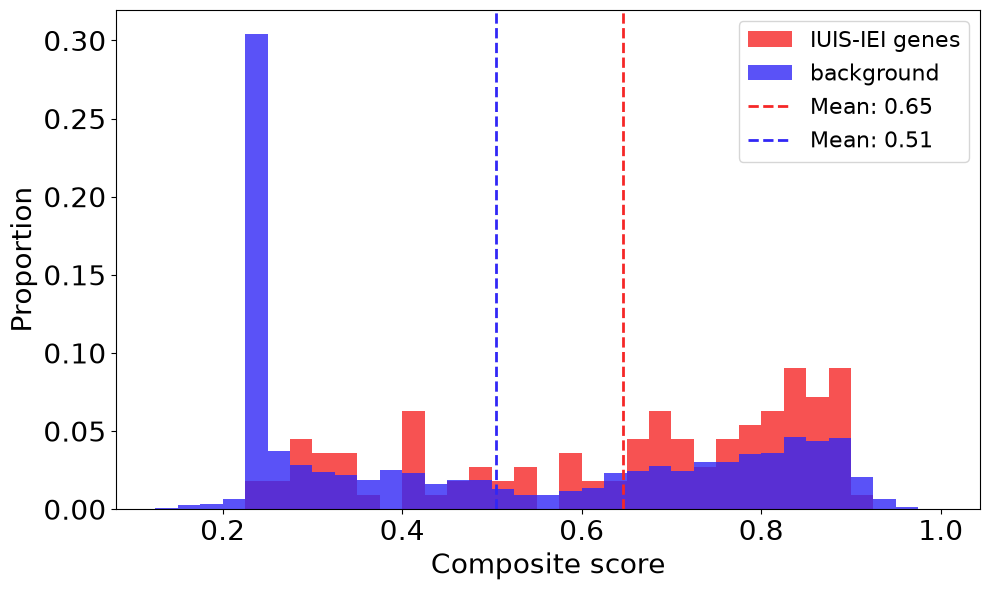

In [38]:
# ============================================================
#       Plot: IUIS-IEI vs background histogram
# ============================================================

df_comp_backg = df_comp_score.filter(
    ~pl.col("human_entryId").is_in(
        df_iuis_iei["Uniprot"].implode()
    )
)

df_comp_backg_unique = (
    df_comp_backg
    .sort("composite_score", descending=True)
    .unique("human_entryId", keep="first")
).sort("composite_score", descending=True)


def double_hist(
    col_1: pl.Series,
    col_2: pl.Series,
    label_1: str,
    label_2: str,
    x_label: str,
    y_label: str,
    bin_width: float,
    colour_1: str = "#F52727",
    colour_2: str = "#3127F5",
    dims: tuple[int, int] = (10, 6),
    alpha: float = 0.8,
    axis_font_size: int = 20,
    label_font_size: int = 16,
    out: str | None = None,
    mean_lines: bool = False
):
    min_val = min(col_1.min(), col_2.min())
    max_val = max(col_1.max(), col_2.max())

    bins = np.arange(
        np.floor(min_val / bin_width) * bin_width,
        np.ceil(max_val / bin_width) * bin_width + bin_width,
        bin_width,
    )
    plt.figure(figsize=dims)
    plt.hist(
        col_1.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        label=label_1,
        color=colour_1,
        weights=np.ones(len(col_1.drop_nulls())) / len(col_1.drop_nulls()),
    )
    plt.hist(
        col_2.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        label=label_2,
        color=colour_2,
        weights=np.ones(len(col_2.drop_nulls())) / len(col_2.drop_nulls()),
    )
    if mean_lines:
        plt.axvline(col_1.mean(), color=colour_1, linestyle="--", linewidth=2, label=f"Mean: {col_1.mean():.2f}")
        plt.axvline(col_2.mean(), color=colour_2, linestyle="--", linewidth=2, label=f"Mean: {col_2.mean():.2f}")

    plt.xlabel(x_label, fontsize=axis_font_size)
    plt.ylabel(y_label, fontsize=axis_font_size)
    plt.xticks(fontsize=axis_font_size)
    plt.yticks(fontsize=axis_font_size)
    plt.legend(fontsize=label_font_size)
    plt.tight_layout()

    if out is not None:
        plt.savefig(f"{out}.svg")
        plt.savefig(f"{out}.png", dpi=300)

    plt.show()
    return None

double_hist(
    col_1=df_comp_iei_unique["composite_score"],
    col_2=df_comp_backg_unique["composite_score"],
    label_1="IUIS-IEI genes",
    label_2="background",
    x_label="Composite score",
    y_label="Proportion",
    bin_width=0.025,
    alpha=0.8,
    out=f"{OUT_DIR_PLOT}/hist_IUIS-IEI_background",
    mean_lines=True
)

In [ ]:
# ============================================================
#       Permutation test
# ============================================================

def two_sample_permuation(
    sample_1: pl.Series,
    sample_2: pl.Series,
    iterations: int = 1000
) -> pl.DataFrame:

    data = pl.concat([sample_1, sample_2])
    n_1 = len(sample_1)
    n_2 = len(sample_2)

    sample_1_mean = []
    sample_2_mean = []
    diff_mean = []

    for _ in range(iterations):
        shuffled = data.sample(
            n = n_1 + n_2,
            with_replacement=False,
            shuffle=True
        )
        random_sample_1 = shuffled.head(n_1)
        random_sample_2 = shuffled.head(n_2)

        mean_1 = random_sample_1.mean()
        mean_2 = random_sample_2.mean()
        sample_1_mean.append(mean_1)
        sample_2_mean.append(mean_2)
        diff_mean.append(abs(mean_1 - mean_2))

    return pl.DataFrame({
        "sample_1_mean": sample_1_means,
        "sample_2_mean": sample_2_means,
        "diff_means": diff_means,
    })

In [34]:
df_tmp = (
    df_comp_score
    .sort("composite_score", descending=True)
    .unique("human_entryId", keep="first")
)
df_tmp["composite_score"].mean()

0.5060684112509632

In [33]:
tmp = len(df_comp_backg_unique["composite_score"])
tmp

15461